In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout
import cv2
from tqdm import tqdm
import tqdm as notebook_tqdm
import imutils
import pywt

2026-04-17 09:02:39.286832: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from skimage.exposure import equalize_adapthist
from skimage.filters import gaussian as sk_gaussian
from tqdm import tqdm
import psutil

DIM         = 128
NUM_CLASSES = 2

TRAIN_DIR = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/train'
TEST_DIR  = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test'

# ── Load raw data ─────────────────────────────────────────────────────────────
def load_data(data_dir, dim=DIM):
    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='int',
        image_size=(dim, dim),
        batch_size=None,
        shuffle=False
    )
    x = np.array([item[0].numpy() for item in ds])
    y = np.array([item[1].numpy() for item in ds])
    return x, y

print('Loading training data...')
x_train_raw, y_train_int = load_data(TRAIN_DIR)
print('Loading test data...')
x_test_raw,  y_test_int  = load_data(TEST_DIR)

n_train, n_test = len(x_train_raw), len(x_test_raw)
print(f'Train: {n_train} | Test: {n_test}')

# Verify class order — Keras sorts alphabetically
class_names = sorted(os.listdir(TRAIN_DIR))
print(f'Class order: {class_names}')  # [NORMAL, PNEUMONIA] -> 0, 1

# ── Grayscale + normalise ─────────────────────────────────────────────────────
def to_gray_norm(images_rgb, N):
    out = np.empty((N, DIM, DIM), dtype=np.float32)
    for i in tqdm(range(N), desc='Grayscale+Norm'):
        gray   = cv2.cvtColor(images_rgb[i].astype(np.uint8),
                               cv2.COLOR_RGB2GRAY)
        out[i] = gray / 255.0
    return out

x_train_gray = to_gray_norm(x_train_raw, n_train)
x_test_gray  = to_gray_norm(x_test_raw,  n_test)
del x_train_raw, x_test_raw

# ── One-hot labels ────────────────────────────────────────────────────────────
y_train = to_categorical(y_train_int, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_int,  num_classes=NUM_CLASSES)

# ── Preprocessing — CLAHE + central crop + smoothing (no segmentation) ────────
def preprocess_xray(img):
    """
    Input : (64, 64) float32 in [0,1] — grayscale, normalised
    Output: (64, 64) float32 in [0,1]
    Steps : CLAHE → fixed central crop → resize → Gaussian smooth → renorm
    """
    # 1. CLAHE
    img = equalize_adapthist(img, clip_limit=0.03).astype(np.float32)
    # 2. Fixed central crop — removes chest wall borders
    h, w  = img.shape
    pad_h = int(h * 0.10)
    pad_w = int(w * 0.08)
    img   = img[pad_h:h-pad_h, pad_w:w-pad_w]
    # 3. Resize back to 64x64
    img = cv2.resize(img, (DIM, DIM), interpolation=cv2.INTER_AREA)
    # 4. Gaussian smoothing
    img = sk_gaussian(img, sigma=0.5).astype(np.float32)
    # 5. Re-normalise
    if img.max() > 1e-8:
        img = img / img.max()
    return img

print('Preprocessing training images...')
x_train = np.zeros((n_train, DIM, DIM), dtype=np.float32)
for i in tqdm(range(n_train), desc='Train'):
    x_train[i] = preprocess_xray(x_train_gray[i])

print('Preprocessing test images...')
x_test = np.zeros((n_test, DIM, DIM), dtype=np.float32)
for i in tqdm(range(n_test), desc='Test'):
    x_test[i] = preprocess_xray(x_test_gray[i])

del x_train_gray, x_test_gray

# ── Verify class split ────────────────────────────────────────────────────────
N_NORMAL    = int(np.sum(y_train_int == 0))
N_PNEUMONIA = int(np.sum(y_train_int == 1))
print(f'\nNormal    : {N_NORMAL}  (idx 0 to {N_NORMAL-1})')
print(f'Pneumonia : {N_PNEUMONIA}  (idx {N_NORMAL} to {n_train-1})')
print(f'x_train   : {x_train.shape}')
print(f'x_test    : {x_test.shape}')

ram = psutil.virtual_memory()
print(f'RAM available: {ram.available/1e9:.1f} GB')


Loading training data...
Found 5216 files belonging to 2 classes.


I0000 00:00:1776441763.070224    2112 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7535 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-04-17 09:02:49.679266: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Loading test data...
Found 624 files belonging to 2 classes.


2026-04-17 09:02:56.804466: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-17 09:02:58.394195: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train: 5216 | Test: 624
Class order: ['NORMAL', 'PNEUMONIA']


...

Preprocessing training images...


Train: 100%|██████████| 5216/5216 [00:16<00:00, 320.86it/s]


Preprocessing test images...


Test: 100%|██████████| 624/624 [00:01<00:00, 357.48it/s]


Normal    : 1341  (idx 0 to 1340)
Pneumonia : 3875  (idx 1341 to 5215)
x_train   : (5216, 128, 128)
x_test    : (624, 128, 128)
RAM available: 12.0 GB


In [3]:
import numpy as np

def estimate_sigma_from_image(image, percentile=10):
    """
    Estimates Gaussian noise sigma from a single image using the
    low-intensity background region.

    For chest X-rays, background pixels approximate Gaussian noise
    with zero mean. We estimate sigma as the std of background pixels.

    Parameters
    ----------
    image      : (H, W) single image, values in [0, 1]
    percentile : float — pixels below this percentile treated as background

    Returns
    -------
    sigma : float — estimated noise standard deviation
    """
    threshold         = np.percentile(image, percentile)
    background_pixels = image[image <= threshold]

    if len(background_pixels) < 10:
        return float(np.std(image))

    sigma = float(np.std(background_pixels))
    return max(sigma, 1e-8)


def compute_single_pair_fi_heatmap(image1, image2):
    """
    Computes the pairwise Gaussian Fisher Information heatmap between
    two individual images from different classes.

    Under the Gaussian noise model:
        I(A) = 1 / sigma^2   (exact closed form, no integration needed)

    Pairwise FI at pixel (i,j):
        FI(i,j) = (M1(i,j) - M2(i,j))^2 / (sigma1^2 + sigma2^2)

    After normalisation to [0,1], sigma cancels — the map reduces to
    the normalised squared pixel difference, which is the correct
    high-SNR limit of the Rician FI.

    Parameters
    ----------
    image1 : (H, W) array — single image from class 1 (Normal)
    image2 : (H, W) array — single image from class 2 (Pneumonia)

    Returns
    -------
    fi_map : (H, W) pairwise FI heatmap, normalised to [0, 1]
    """
    # Estimate sigma globally from background of each image
    sigma1 = estimate_sigma_from_image(image1)
    sigma2 = estimate_sigma_from_image(image2)

    # Gaussian FI: I(A) = 1/sigma^2
    # Pairwise: FI = (M1 - M2)^2 / (sigma1^2 + sigma2^2)
    numerator   = (image1.astype(np.float32) - image2.astype(np.float32))**2
    denominator = sigma1**2 + sigma2**2 + 1e-10

    fi_map = numerator / denominator

    # Normalise to [0, 1]
    fi_max = fi_map.max()
    if fi_max > 1e-10:
        fi_map = fi_map / fi_max

    return fi_map.astype(np.float32)


In [ ]:
def visualise_single_pair_fi(image1, image2, fi_map,
                              class1_name='Class 1',
                              class2_name='Class 2'):
    """
    Visualises two input images alongside their pairwise Gaussian FI heatmap.
    """
    fig, axes = plt.subplots(3,1, figsize=(6, 18))

    axes[0].imshow(image1, cmap='gray')
    axes[0].set_title(f'{class1_name}', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(image2, cmap='gray')
    axes[1].set_title(f'{class2_name}', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    im = axes[2].imshow(fi_map, cmap='viridis', vmin=0, vmax=1)
    axes[2].set_title(f'Gaussian FI\n{class1_name} vs {class2_name}',
                      fontsize=14, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.suptitle('Single-Pair Gaussian Fisher Information Heatmap',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    #plt.savefig('gaussian_fi_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


   

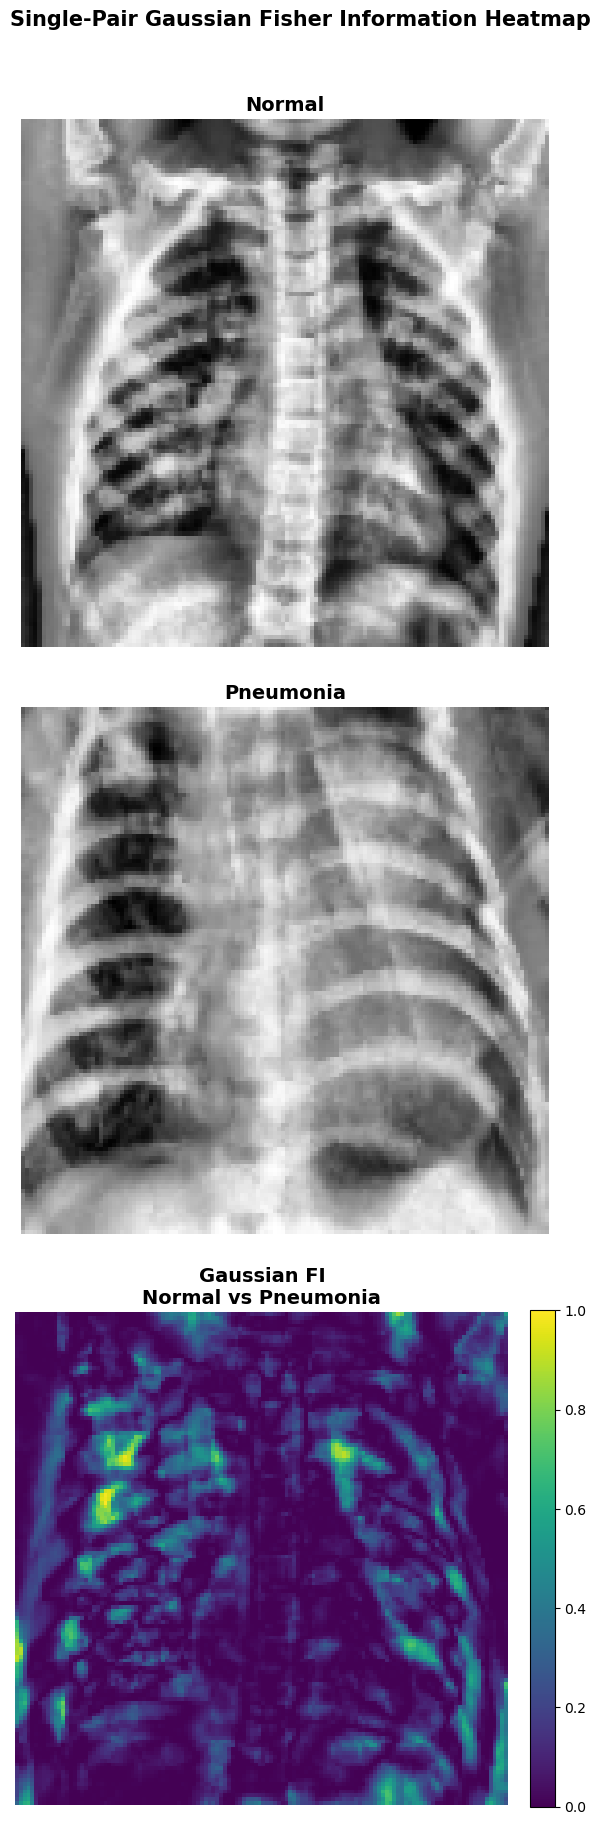

ValueError: operands could not be broadcast together with shapes (128,128) (64,64) 

In [14]:
fi = compute_single_pair_fi_heatmap(x_train[0], x_train[3000])

visualise_single_pair_fi(x_train[0], x_train[3000], fi,
                          class1_name='Normal', class2_name='Pneumonia')

In [6]:
import numpy as np

N_PAIRS     = 100_000
# N_NORMAL and N_PNEUMONIA set in Cell 1
rng = np.random.default_rng(seed=42)

normal_indices    = rng.integers(0,        N_NORMAL,              size=N_PAIRS)
pneumonia_indices = rng.integers(N_NORMAL, N_NORMAL + N_PNEUMONIA, size=N_PAIRS)

assert normal_indices.min() >= 0
assert normal_indices.max() <= N_NORMAL - 1
assert pneumonia_indices.min() >= N_NORMAL
assert pneumonia_indices.max() <= n_train - 1

pairs = np.stack([normal_indices, pneumonia_indices], axis=1)

print(f'Normal    — min: {normal_indices.min()}, max: {normal_indices.max()}')
print(f'Pneumonia — min: {pneumonia_indices.min()}, max: {pneumonia_indices.max()}')
print(f'Pairs shape: {pairs.shape}')


Normal    — min: 0, max: 1340
Pneumonia — min: 1341, max: 5215
Pairs shape: (100000, 2)


In [7]:
import numpy as np
import time

DIM       = 64
N_PAIRS   = 100_000
FI_PATH   = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/fi_diff_gaussian_100k.npy'

# Memory-mapped — writes directly to disk, negligible RAM
fi_diff_maps = np.lib.format.open_memmap(
    FI_PATH,
    mode='w+',
    dtype=np.float32,
    shape=(N_PAIRS, DIM, DIM)
)

print(f'Generating {N_PAIRS:,} Gaussian FI difference maps...')
t0 = time.time()

for k in range(N_PAIRS):
    img_n = x_train[pairs[k, 0]]   # normal image    (64, 64)
    img_p = x_train[pairs[k, 1]]   # pneumonia image  (64, 64)

    fi_diff_maps[k] = compute_single_pair_fi_heatmap(img_n, img_p)

    if k % 10_000 == 0:
        fi_diff_maps.flush()
        elapsed = time.time() - t0
        rate    = k / elapsed if elapsed > 0 else 0
        eta     = (N_PAIRS - k) / rate if rate > 0 else 0
        print(f'{k:>7,}/{N_PAIRS:,} | elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s')

fi_diff_maps.flush()
print(f'\nDone in {(time.time()-t0):.1f}s')
print(f'Saved to: {FI_PATH}')
print(f'File size: {N_PAIRS * DIM * DIM * 4 / 1e6:.1f} MB')


Generating 100,000 Gaussian FI difference maps...
      0/100,000 | elapsed: 0s | ETA: 0s
 10,000/100,000 | elapsed: 10s | ETA: 89s
 20,000/100,000 | elapsed: 19s | ETA: 75s
 30,000/100,000 | elapsed: 28s | ETA: 66s
 40,000/100,000 | elapsed: 36s | ETA: 54s
 50,000/100,000 | elapsed: 45s | ETA: 45s
 60,000/100,000 | elapsed: 53s | ETA: 35s
 70,000/100,000 | elapsed: 62s | ETA: 27s
 80,000/100,000 | elapsed: 71s | ETA: 18s
 90,000/100,000 | elapsed: 80s | ETA: 9s

Done in 88.8s
Saved to: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/fi_diff_gaussian_100k.npy
File size: 1638.4 MB


In [12]:
import numpy as np

DIM     = 64
xmax    = 10
dx      = 2 * xmax / DIM
flambda = 80
m2 = 1 
m3 = 3

x    = np.linspace(-xmax, xmax - dx, DIM)
X, Y = np.meshgrid(x, x)
R2   = X**2 + Y**2
T    = np.arctan2(Y, X)

# ── Original vortex masks (edge enhancement — DC suppressed) ──────────────────
Lens = np.exp(-1j * R2 / (flambda / 10))
LG1  = Lens * np.exp(1j * m2 * T)   # m=1
LG2  = Lens * np.exp(1j * m3 * T)   # m=3

# ── Inverse vortex masks (DC enhancement — edges suppressed) ──────────────────
# Negate the topological charge: e^{-im*theta} reverses the spiral phase
# The lens term is kept identical — same focusing geometry
# The negative charge concentrates energy back toward DC
# instead of destructively interfering at it
ILG1 = Lens * np.exp(-1j * 1 * T)  # m=-1 (inverse vortex)
ILG2 = Lens * np.exp(-1j * 3 * T)  # m=-3 (inverse vortex)

def myfft2(A):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(A)))

def generate_fi_speckle(fi_map):
    """
    Original vortex speckle — edge enhancing.
    DC suppressed via positive topological charge.
    Suitable for boundary-based pathologies (brain tumors).

    Returns
    -------
    speckle : (64, 128) float32 in [-1, 1]
    """
    phase = np.exp(1j * fi_map.astype(np.float64) * np.pi * 2)

    A1     = np.abs(myfft2(phase * LG1)).astype(np.float32)
    A1_min = A1.min(); A1_rng = A1.max() - A1_min
    A1     = (A1 - A1_min) / A1_rng * 2 - 1 if A1_rng > 1e-8 else A1 * 0

    A2     = np.abs(myfft2(phase * LG2)).astype(np.float32)
    A2_min = A2.min(); A2_rng = A2.max() - A2_min
    A2     = (A2 - A2_min) / A2_rng * 2 - 1 if A2_rng > 1e-8 else A2 * 0

    return np.hstack((A1, A2)).astype(np.float32)


def generate_fi_speckle_inverse(fi_map):
    """
    Inverse vortex speckle — DC enhancing / low-pass.
    Negative topological charge reverses the spiral phase,
    concentrating energy at DC instead of nulling it.
    Preserves bulk regional intensity — the consolidation
    opacity signal relevant for pneumonia detection.

    Returns
    -------
    speckle : (64, 128) float32 in [-1, 1]
    """
    phase = np.exp(1j * fi_map.astype(np.float64) * np.pi * 2)

    A1     = np.abs(myfft2(phase * ILG1)).astype(np.float32)
    A1_min = A1.min(); A1_rng = A1.max() - A1_min
    A1     = (A1 - A1_min) / A1_rng * 2 - 1 if A1_rng > 1e-8 else A1 * 0

    A2     = np.abs(myfft2(phase * ILG2)).astype(np.float32)
    A2_min = A2.min(); A2_rng = A2.max() - A2_min
    A2     = (A2 - A2_min) / A2_rng * 2 - 1 if A2_rng > 1e-8 else A2 * 0

    return np.hstack((A1, A2)).astype(np.float32)




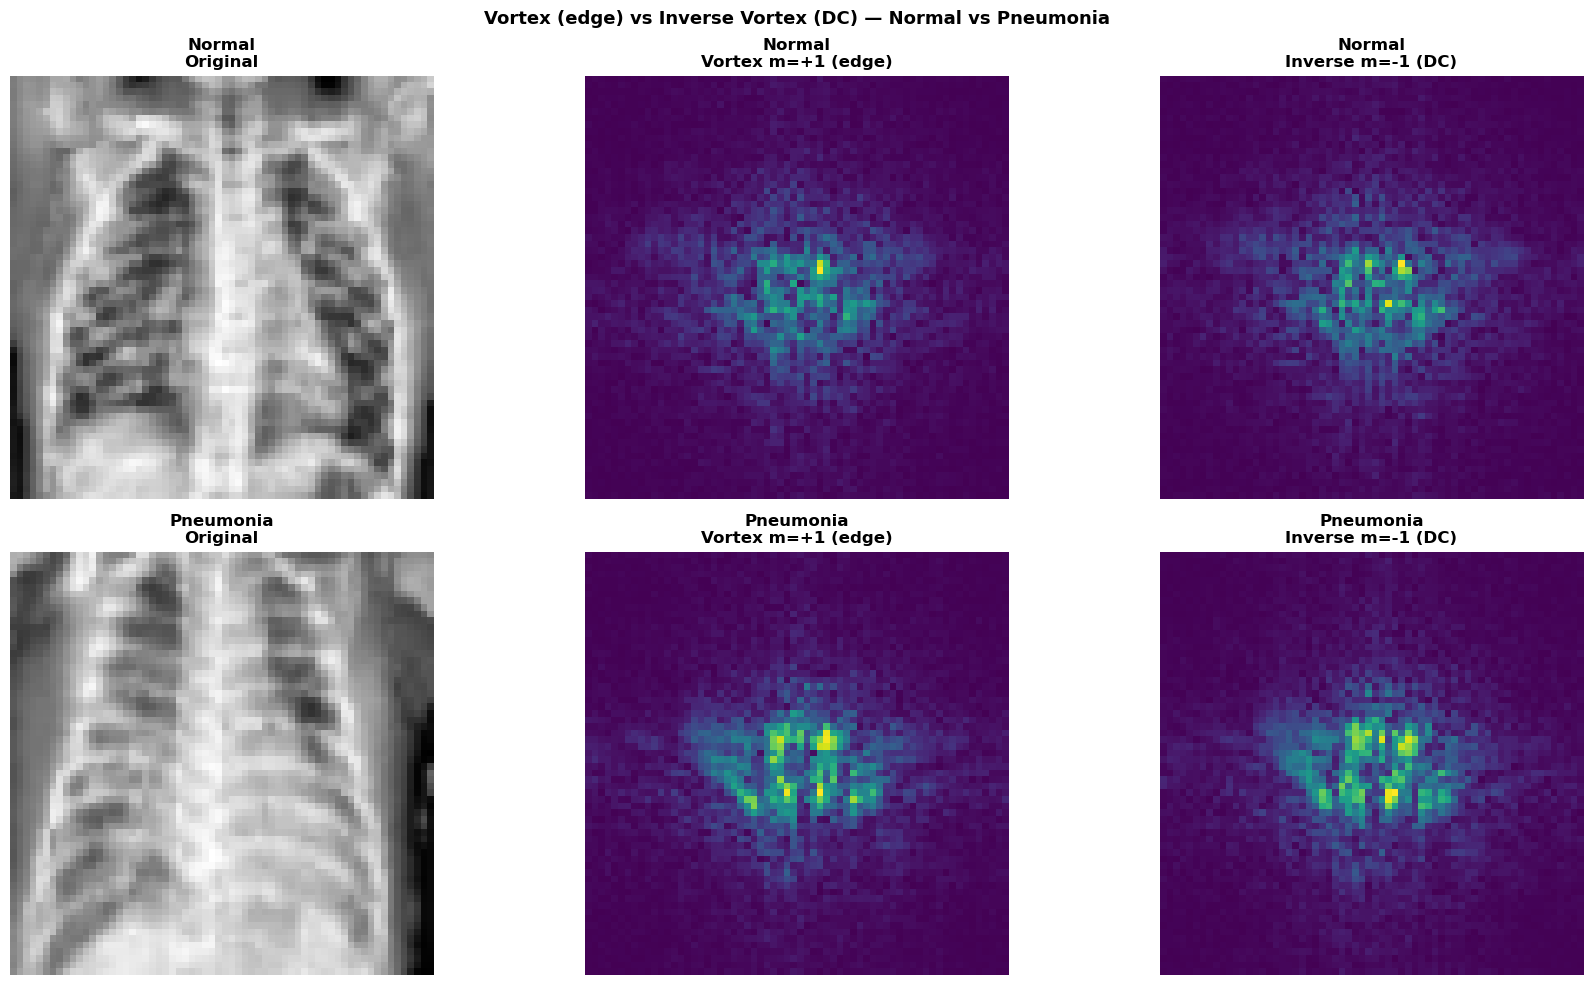

Masks ready:
  LG1/LG2   — m=+1/+3  (vortex, edge enhancement)
  ILG1/ILG2 — m=-1/-3  (inverse vortex, DC enhancement)


In [ ]:
# ── Quick visual comparison ───────────────────────────────────────────────────
y_ints        = np.argmax(y_train, axis=1)
img_normal    = x_train[np.where(y_ints == 0)[0][0]]
img_pneumonia = x_train[np.where(y_ints == 1)[0][0]]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (img, label) in enumerate([(img_normal,    'Normal'),
                                     (img_pneumonia, 'Pneumonia')]):
    s_vortex  = generate_fi_speckle(img)
    s_inverse = generate_fi_speckle_inverse(img)

    axes[row, 0].imshow(img,              cmap='gray')
    axes[row, 0].set_title(f'{label}\nOriginal',            fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(s_vortex[:, :64], cmap='viridis')
    axes[row, 1].set_title(f'{label}\nVortex m=+1 (edge)',  fontweight='bold')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(s_inverse[:, :64], cmap='viridis')
    axes[row, 2].set_title(f'{label}\nInverse m=-1 (DC)',   fontweight='bold')
    axes[row, 2].axis('off')

plt.suptitle('Vortex (edge) vs Inverse Vortex (DC) — Normal vs Pneumonia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vortex_vs_inverse_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('Masks ready:')
print('  LG1/LG2   — m=+1/+3  (vortex, edge enhancement)')
print('  ILG1/ILG2 — m=-1/-3  (inverse vortex, DC enhancement)')


In [ ]:
import numpy as np
import time

N_PAIRS      = 100_000
DIM          = 64
SPECKLE_PATH = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/fi_inverse_speckles_100k.npy'

# Reload FI maps (memory-mapped)
fi_diff_maps = np.load(
    '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/fi_diff_gaussian_100k.npy',
    mmap_mode='r'
)

# Memory-mapped speckle file — (100000, 8192) float32 = 3.2 GB on disk
speckles = np.lib.format.open_memmap(
    SPECKLE_PATH,
    mode='w+',
    dtype=np.float32,
    shape=(N_PAIRS, DIM * DIM * 2)   # 8192 per sample
)

print(f'Generating {N_PAIRS:,} dual-channel vortex speckles...')
print(f'Saving to: {SPECKLE_PATH}')
t0 = time.time()

for k in range(N_PAIRS):
    speckle     = generate_fi_speckle(fi_diff_maps[k])   # (64, 128)
    speckles[k] = speckle.flatten()                       # (8192,)

    if k % 10_000 == 0:
        speckles.flush()
        elapsed = time.time() - t0
        rate    = k / elapsed if elapsed > 0 else 0
        eta     = (N_PAIRS - k) / rate if rate > 0 else 0
        print(f'{k:>7,}/{N_PAIRS:,} | elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s')

speckles.flush()
print(f'\nDone in {(time.time()-t0):.1f}s')
print(f'Speckles shape : {speckles.shape}')
print(f'File size      : {N_PAIRS * DIM * DIM * 2 * 4 / 1e9:.2f} GB')


In [ ]:
import numpy as np
import psutil
import time
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

DIM        = 64
BATCH_SIZE = 512

# ── Check available RAM ───────────────────────────────────────────────────────
ram            = psutil.virtual_memory()
per_pair_bytes = (DIM*DIM*2 + DIM*DIM) * 4   # speckle(8192) + fi_map(4096), float32
safe_pairs     = int((ram.available - 2e9) / per_pair_bytes)  # 2GB headroom
N_RAM          = min(safe_pairs, 100_000)

print(f'Available RAM  : {ram.available/1e9:.1f} GB')
print(f'Safe pairs     : {safe_pairs:,}')
print(f'Loading N_RAM  : {N_RAM:,} pairs')

# ── Load into RAM ─────────────────────────────────────────────────────────────
speckles     = np.load('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/fi_speckles_100k.npy',    mmap_mode='r')
fi_diff_maps = np.load('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/fi_diff_gaussian_100k.npy', mmap_mode='r')

t0    = time.time()
X_ram = np.array(speckles[:N_RAM],                           dtype=np.float32)  # (N, 8192)
Y_ram = fi_diff_maps[:N_RAM].reshape(N_RAM, -1).astype(np.float32)              # (N, 4096)
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'X_ram : {X_ram.nbytes/1e9:.2f} GB | Y_ram : {Y_ram.nbytes/1e9:.2f} GB')

# ── Build reconstruction model ────────────────────────────────────────────────
def build_reconstruction_model(dim=64):
    """
    Input:  8192 — flattened 64x128 dual-channel vortex speckle (m=1 | m=3)
    Output: 4096 — flattened 64x64 FI difference map
    Single linear layer — same architecture as Baurzhan.
    """
    model = Sequential([
        Dense(dim**2, input_dim=dim**2 * 2,
              activation='linear', use_bias=False)
    ])
    model.compile(loss='MSE', optimizer=Adam(), metrics=['mae'])
    return model

recon_model = build_reconstruction_model(DIM)
recon_model.summary()

# ── Train ─────────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=50,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=20, min_lr=1e-6, verbose=1)
]

print('\nTraining...')
t0      = time.time()
history = recon_model.fit(
    X_ram, Y_ram,
    validation_split=0.1,
    batch_size=BATCH_SIZE,
    epochs=5000,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

print(f'Stopped at epoch : {len(history.history["loss"])}')
print(f'Total time       : {(time.time()-t0)/60:.1f} min')

# ── Save ──────────────────────────────────────────────────────────────────────
SAVE_MODEL = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/recon_fi_vortex.keras'
recon_model.save(SAVE_MODEL)
print(f'Saved to:\n{SAVE_MODEL}')

# ── Plot training curve ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val',   linewidth=2)
axes[0].set_title('MSE Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val',   linewidth=2)
axes[1].set_title('MAE', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('FI-Guided Reconstruction Model (m=1 + m=3 Vortex)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('recon_fi_training.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
SAVE_MODEL = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/recon_fi_vortex.keras'
recon_model.save(SAVE_MODEL)
print(f'Saved. Val loss: {min(history.history["val_loss"]):.6f}')

In [8]:
CUSTOM_OBJECTS = {
            # 1. Metrics (Likely Source of Error)
            'keras.metrics.MSE': tf.keras.metrics.MeanSquaredError(),
            'MSE': tf.keras.metrics.MeanSquaredError(),
            'mse': tf.keras.metrics.MeanSquaredError(),
            
            # 2. Loss Functions (Possible Source of Error)
            'mean_squared_error': tf.keras.losses.MeanSquaredError(),
            
            # 3. Optimizers (Needed if you want to resume training, though not needed for prediction)
            'rmsprop': tf.keras.optimizers.RMSprop() 
        }


model_path = f'/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/recon_fi_vortex.keras'
reconstruction_model = load_model(model_path, custom_objects=CUSTOM_OBJECTS)

x_train_transformed = np.array([generate_fi_speckle(x_train[i]) for i in range(len(x_train))], dtype=np.float32)
recon_train = reconstruction_model.predict(x_train_transformed.reshape(len(x_train_transformed), 2*64**2)).reshape(-1, 64, 64)

x_test_transformed = np.array([generate_fi_speckle(x_test[i]) for i in range(len(x_test))], dtype=np.float32)
recon_test = reconstruction_model.predict(x_test_transformed.reshape(len(x_test_transformed), 2*64**2)).reshape(-1, 64, 64)


2026-04-08 22:51:51.934184: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d4924003c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-08 22:51:51.934229: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-04-08 22:51:51.941814: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-04-08 22:51:52.402926: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 60 bytes spill stores, 60 bytes spill loads



 42/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

I0000 00:00:1775713912.678984  673390 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


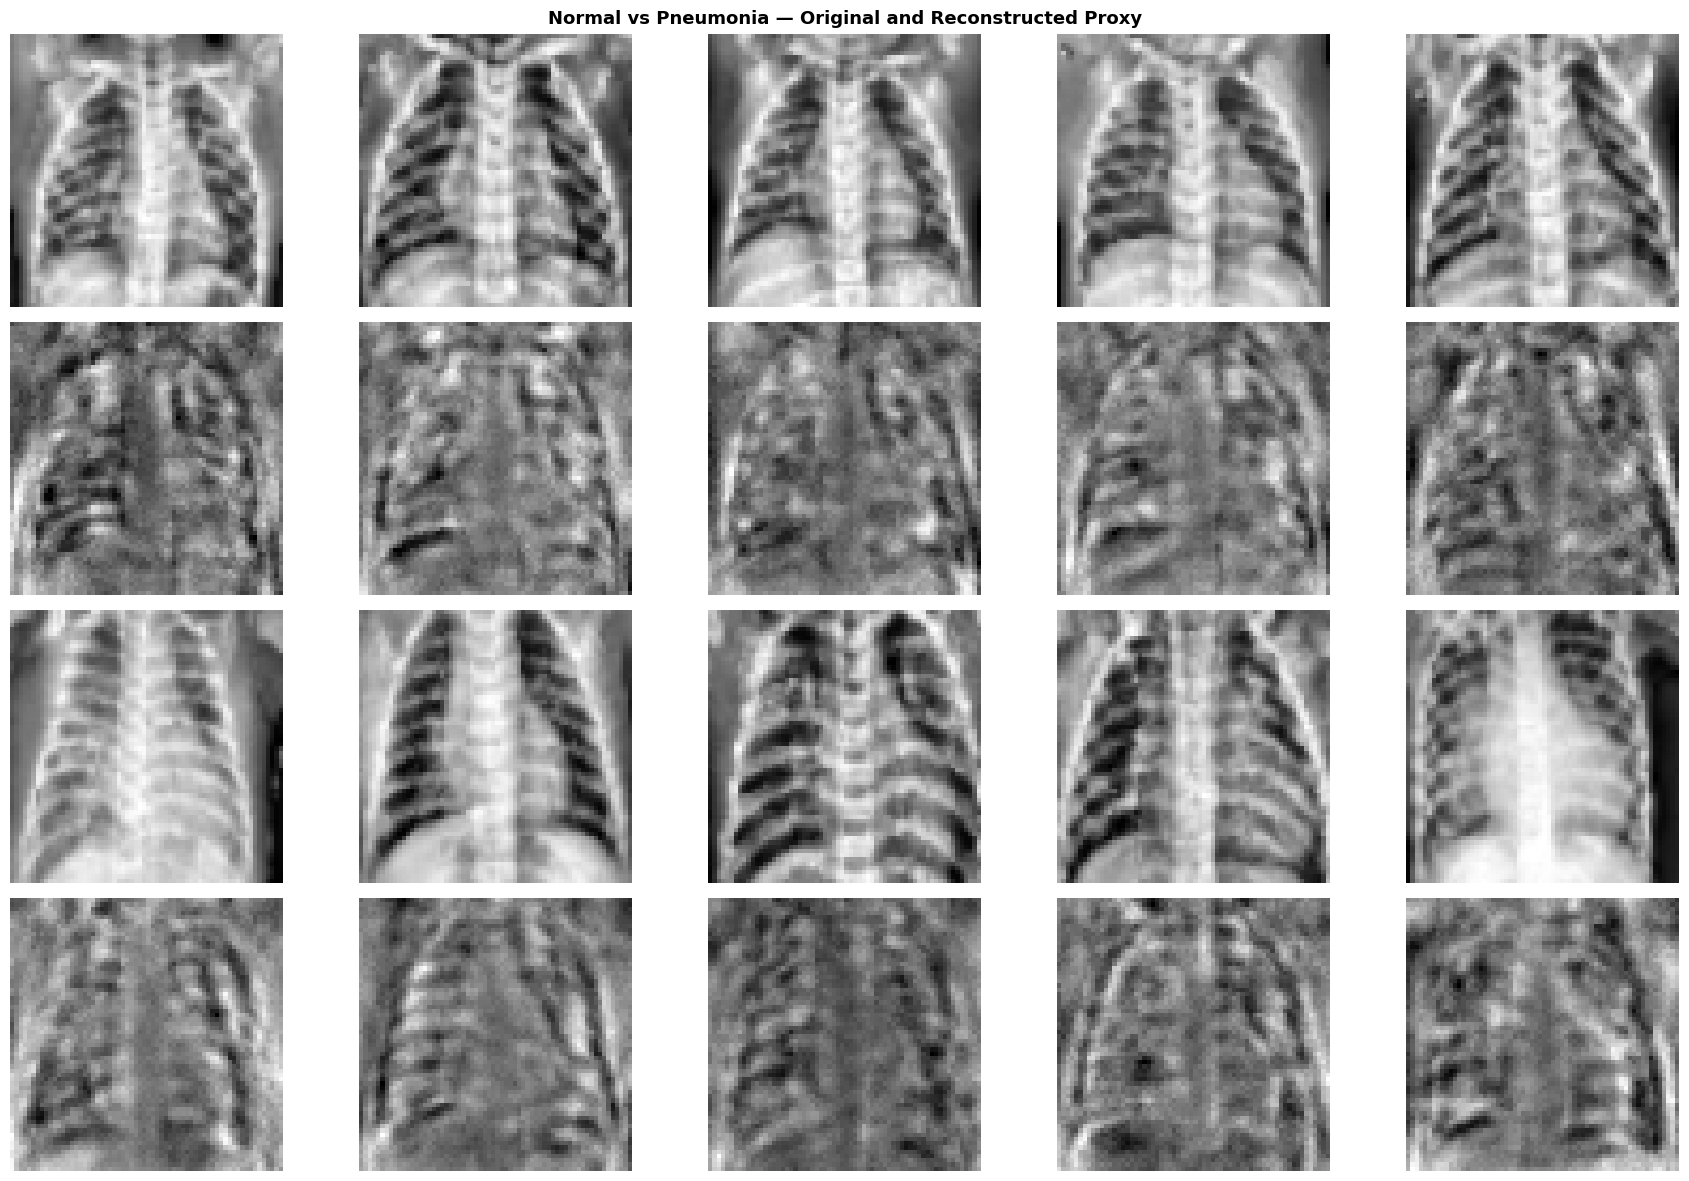

In [20]:
y_ints = np.argmax(y_train, axis=1)

normal_idx    = np.where(y_ints == 0)[0][:5]
pneumonia_idx = np.where(y_ints == 1)[0][:5]

fig, axes = plt.subplots(4, 5, figsize=(18, 12))

for col in range(5):
    # Row 0: Normal original
    axes[0, col].imshow(x_train[normal_idx[col]],       cmap='gray')
    axes[0, col].axis('off')

    # Row 1: Normal reconstructed
    axes[1, col].imshow(recon_train[normal_idx[col]],   cmap='gray')
    axes[1, col].axis('off')

    # Row 2: Pneumonia original
    axes[2, col].imshow(x_train[pneumonia_idx[col]],    cmap='gray')
    axes[2, col].axis('off')

    # Row 3: Pneumonia reconstructed
    axes[3, col].imshow(recon_train[pneumonia_idx[col]], cmap='gray')
    axes[3, col].axis('off')

axes[0, 0].set_ylabel('Normal\nOriginal',       fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Normal\nReconstructed',  fontsize=10, fontweight='bold')
axes[2, 0].set_ylabel('Pneumonia\nOriginal',    fontsize=10, fontweight='bold')
axes[3, 0].set_ylabel('Pneumonia\nReconstructed', fontsize=10, fontweight='bold')

plt.suptitle('Normal vs Pneumonia — Original and Reconstructed Proxy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

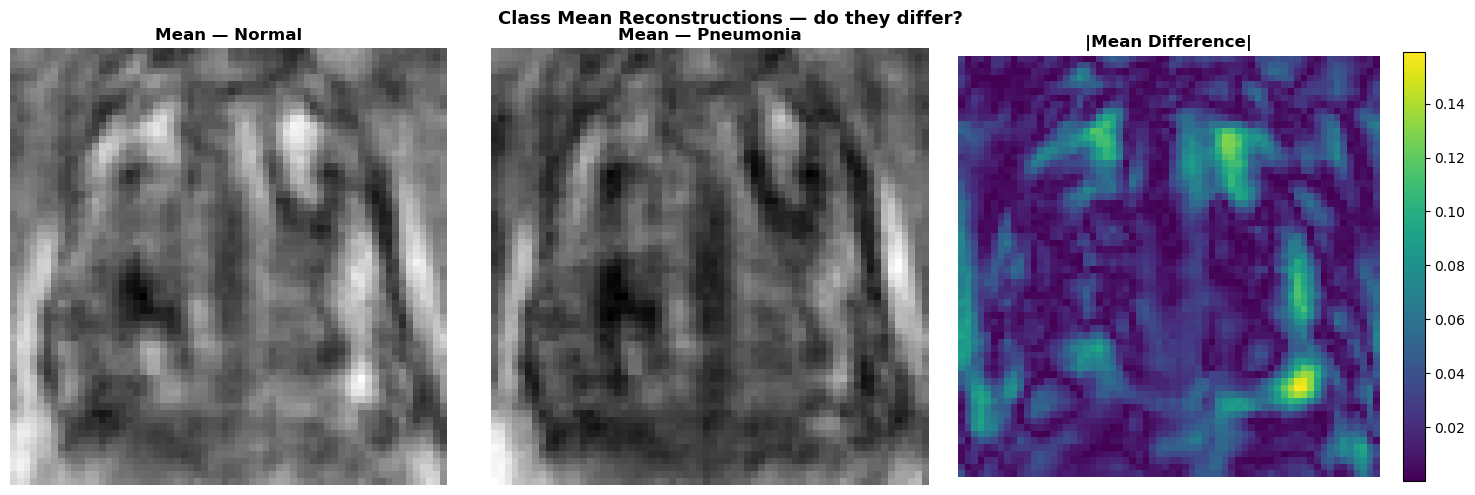

In [10]:
y_ints = np.argmax(y_train, axis=1)

mean_normal    = np.mean(recon_train[y_ints == 0], axis=0)
mean_pneumonia = np.mean(recon_train[y_ints == 1], axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mean_normal,               cmap='gray')
axes[0].set_title('Mean — Normal',        fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mean_pneumonia,            cmap='gray')
axes[1].set_title('Mean — Pneumonia',     fontweight='bold')
axes[1].axis('off')

diff = np.abs(mean_normal - mean_pneumonia)
im   = axes[2].imshow(diff,               cmap='viridis')
axes[2].set_title('|Mean Difference|',    fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.suptitle('Class Mean Reconstructions — do they differ?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Creates a 2-layer (linear-softmax) NN
# Loss is categorical crossentropy
# This isn't meant to be a 'good' classifier, 
# it is meant to be bad enough so that if an image
# is not salient, accuracy goes to zero.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from tensorflow.keras.optimizers import Adam, SGD

def classifier(num_classes,input_dimen):
    model = Sequential()
    model.add(Dense(input_dimen, input_dim= input_dimen, activation='linear', use_bias=False))
    model.add(Dense(num_classes, kernel_initializer='normal', activation='softmax', use_bias=False))
    model.compile(loss='CategoricalCrossentropy', optimizer=Adam(), metrics=['accuracy'])
    return model

def classifier_linear(num_classes, input_dimen):
    """
    True logistic regression — single linear layer.
    Mathematically identical to your current classifier
    but with half the parameters and no confusion.
    """
    model = Sequential([
        Dense(num_classes,
              input_dim=input_dimen,
              activation='softmax',
              use_bias=True,              # bias back in
              kernel_initializer='glorot_uniform')
    ])
    model.compile(loss='CategoricalCrossentropy',
                  optimizer=Adam(),
                  metrics=['accuracy'])
    return model

def classifier_relu(num_classes, input_dimen, hidden=256):
    model = Sequential([
        Dense(hidden, input_dim=input_dimen,
              activation='relu', use_bias=True,
              kernel_initializer='he_uniform'),
        Dense(num_classes,
              activation='softmax', use_bias=True,
              kernel_initializer='glorot_uniform')
    ])
    model.compile(loss='CategoricalCrossentropy',
                  optimizer=Adam(), metrics=['accuracy'])
    return model

In [19]:
DIM = 64           # Image dimension (256x256)
NUM_CLASSES = 2     # Number of tumor types

# 1. Create a new classifier model (input size is DIM^2)
model = classifier_relu(NUM_CLASSES, DIM**2)

# 2. Fit the classifier on the reconstructed images.
#    Input: Flattened reconstructed image (N_train, DIM^2)
#    Target: One-hot labels (y_train)
model.fit(
    recon_train.reshape(len(recon_train), DIM**2),
    y_train,
    validation_data=(recon_test.reshape(len(recon_test), DIM**2), y_test),
    batch_size=32,                              
    epochs=100,
    verbose=1,
    )

/home/jet/anaconda3/envs/MV/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100


2026-04-08 22:59:34.943228: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-08 22:59:35.193510: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_137', 16 bytes spill stores, 16 bytes spill loads

2026-04-08 22:59:35.960044: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_248', 520 bytes spill stores, 520 bytes spill loads



163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8723 - loss: 0.3066 - val_accuracy: 0.8221 - val_loss: 0.4234
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9208 - loss: 0.2016 - val_accuracy: 0.7260 - val_loss: 0.7706
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9340 - loss: 0.1642 - val_accuracy: 0.7163 - val_loss: 0.8943
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9408 - loss: 0.1469 - val_accuracy: 0.7420 - val_loss: 0.7816
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9375 - loss: 0.1516 - val_accuracy: 0.7115 - val_loss: 1.0576
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9423 - loss: 0.1395 - val_accuracy: 0.8029 - val_loss: 0.5227
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9448 - loss: 0.1426 - val_accuracy: 0.7532 - val_loss: 0.7698
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9498 - loss: 0.1251 - val_accuracy: 0.745

In [17]:
DIM = 64           # Image dimension (256x256)
NUM_CLASSES = 2     # Number of tumor types

# 1. Create a new classifier model (input size is DIM^2)
model = classifier_linear(NUM_CLASSES, DIM**2)

# 2. Fit the classifier on the reconstructed images.
#    Input: Flattened reconstructed image (N_train, DIM^2)
#    Target: One-hot labels (y_train)
model.fit(
    x_train.reshape(len(x_train), DIM**2),
    y_train,
    validation_data=(x_test.reshape(len(x_test), DIM**2), y_test),
    batch_size=32,                              
    epochs=100,
    verbose=1,
    )

/home/jet/anaconda3/envs/MV/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8560 - loss: 0.3489 - val_accuracy: 0.8349 - val_loss: 0.3553
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9266 - loss: 0.1856 - val_accuracy: 0.7083 - val_loss: 0.7389
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9379 - loss: 0.1591 - val_accuracy: 0.7163 - val_loss: 0.7720
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9406 - loss: 0.1520 - val_accuracy: 0.6923 - val_loss: 0.9557
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9448 - loss: 0.1415 - val_accuracy: 0.7612 - val_loss: 0.6382
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9502 - loss: 0.1339 - val_accuracy: 0.7564 - val_loss: 0.6993
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9521 - loss: 0.1239 - val_accuracy: 0.7131 - val_loss: 0.9628
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9528 - loss: 0.1243 - val_accu